In [1]:
# Model Training
# We will be predicting Average

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [54]:
## Feature Engineering

df=pd.read_csv("./data/stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [55]:
# df["total_score"]=df["math_score"]+df["reading_score"]+df["writing_score"]
# df["average"]=df["total_score"]/3

In [56]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [57]:
# I will be predicting math_score against other variables

In [60]:
# Lets check the independent variables correlation values
df.iloc[:,6:].corr()
# This will be handled by Ridge and Lasso Accordingly

,reading_score,writing_score
reading_score,1.000000,0.954598
writing_score,0.954598,1.000000


In [63]:
# The values are too much related -- correlated
# Lets only check for relation with categorical features first

# Defining independent variables
X=df.drop(columns=["math_score"])
y=df["math_score"]

In [64]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [65]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [71]:
# Lets check the categorical values
for feature in df.columns[:5]:
    print(feature)
    print(df[feature].unique())
    print(len(df[feature].unique()))
    print()
ohe_feaures=df.columns[:5]
print(ohe_feaures)
numerical_features=df.columns[-2:]
print(numerical_features)

gender
['female' 'male']
2

race_ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']
5

parental_level_of_education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
6

lunch
['standard' 'free/reduced']
2

test_preparation_course
['none' 'completed']
2

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')
Index(['reading_score', 'writing_score'], dtype='object')


In [72]:
# Here we can use OneHotEncoding for all the categorical 
# Since we will also apply Standard Scaler, so we need to do train test split before standardization, since there is chance of data leakage

In [73]:
## Train Test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(670, 7) (330, 7) (670,) (330,)


In [77]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [78]:
transformer=[
    ("OneHotEncoder",OneHotEncoder(drop="first"),ohe_feaures),
    ("StandardScaler",StandardScaler(),numerical_features)
    ]
ct=ColumnTransformer(transformer,remainder="passthrough",n_jobs=-1)

In [79]:
X_train

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
703,female,group D,some college,standard,none,64,67
311,male,group B,bachelor's degree,standard,none,60,57
722,female,group B,some high school,free/reduced,completed,90,88
629,female,group C,some high school,standard,completed,51,55
0,female,group B,bachelor's degree,standard,none,72,74
...,...,...,...,...,...,...,...
106,female,group D,master's degree,standard,none,100,100
270,male,group C,bachelor's degree,standard,none,63,61
860,female,group C,associate's degree,standard,none,62,53
435,male,group C,some college,free/reduced,completed,48,53


In [81]:
X_train_transformed=ct.fit_transform(X_train)
X_test_transformed=ct.transform(X_test)

In [82]:
print(type(X_train_transformed))
print(X_train_transformed)

<class 'numpy.ndarray'>
[[ 0.          0.          0.         ...  1.         -0.40097854
  -0.10836734]
 [ 1.          1.          0.         ...  1.         -0.68310573
  -0.7881999 ]
 [ 0.          1.          0.         ...  0.          1.43284823
   1.31928104]
 ...
 [ 0.          0.          1.         ...  1.         -0.54204214
  -1.06013293]
 [ 1.          0.          1.         ...  0.         -1.52948732
  -1.06013293]
 [ 0.          0.          0.         ...  1.          1.50338003
   1.3872643 ]]


In [83]:
pd.DataFrame(X_train_transformed,columns=ct.get_feature_names_out())

,OneHotEncoder__gender_male,OneHotEncoder__race_ethnicity_group B,OneHotEncoder__race_ethnicity_group C,OneHotEncoder__race_ethnicity_group D,OneHotEncoder__race_ethnicity_group E,OneHotEncoder__parental_level_of_education_bachelor's degree,OneHotEncoder__parental_level_of_education_high school,OneHotEncoder__parental_level_of_education_master's degree,OneHotEncoder__parental_level_of_education_some college,OneHotEncoder__parental_level_of_education_some high school,OneHotEncoder__lunch_standard,OneHotEncoder__test_preparation_course_none,StandardScaler__reading_score,StandardScaler__writing_score
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,-0.400979,-0.108367
1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.683106,-0.788200
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.432848,1.319281
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-1.317892,-0.924166
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.163276,0.367515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,2.138166,2.135080
666,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.471510,-0.516267
667,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-0.542042,-1.060133
668,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.529487,-1.060133


In [84]:
## Data is Transformed and ready to be trained

In [87]:
## Model Training and Evaluation
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error



models={
    "Linear Regression":LinearRegression(n_jobs=-1),
    "Ridge Regression":Ridge(),
    "Lasso Regression":Lasso(), 
    "Support Vector Regression":SVR(),
    "KNeighborsRegressor":KNeighborsRegressor(n_jobs=-1),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor(),
    "GradientBoostingRegressor":GradientBoostingRegressor(),
    "XGBoostRegressor":XGBRegressor()
}

model_list=models.keys()
r2_list=[]

def reg_evaluation(y_true,y_pred):
    
    
    r2=r2_score(y_true,y_pred)
    rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    mae=mean_absolute_error(y_true,y_pred)
    
    return (r2,rmse,mae)

for model_name,model in models.items():
    
    print(model_name)
    print("-"*30)

    model.fit(X_train_transformed,y_train)
    
    y_train_pred=model.predict(X_train_transformed)
    y_test_pred=model.predict(X_test_transformed)

    print("Evaluation for Training Dataset : (R2, RMSE, MAE)")
    print(reg_evaluation(y_train,y_train_pred))
    print("\nEvaluation for Testing Dataset : (R2, RMSE, MAE)")
    print(reg_evaluation(y_test,y_test_pred))
    r2_list.append(reg_evaluation(y_test,y_test_pred)[0])
    print()


Linear Regression
------------------------------
Evaluation for Training Dataset : (R2, RMSE, MAE)
(0.8751789386653736, 5.26916841702104, 4.20765123313951)

Evaluation for Testing Dataset : (R2, RMSE, MAE)
(0.8755309836850074, 5.49670975976639, 4.37031487430096)

Ridge Regression
------------------------------
Evaluation for Training Dataset : (R2, RMSE, MAE)
(0.8751516655422504, 5.269744036345286, 4.20761688934203)

Evaluation for Testing Dataset : (R2, RMSE, MAE)
(0.875440995353606, 5.4986964002293774, 4.3689144367619654)

Lasso Regression
------------------------------
Evaluation for Training Dataset : (R2, RMSE, MAE)
(0.8081251766576159, 6.532917006872188, 5.17446094478312)

Evaluation for Testing Dataset : (R2, RMSE, MAE)
(0.8094556194525845, 6.800960456628569, 5.3501139137934315)

Support Vector Regression
------------------------------
Evaluation for Training Dataset : (R2, RMSE, MAE)
(0.7804620767338286, 6.988000386935398, 5.081233801074986)

Evaluation for Testing Dataset : (R

In [88]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=["Model_Name","R2_Score"]).sort_values(by=["R2_Score"],ascending=False)

,Model_Name,R2_Score
0,Linear Regression,0.875531
1,Ridge Regression,0.875441
8,GradientBoostingRegressor,0.866027
6,RandomForestRegressor,0.847999
7,AdaBoostRegressor,0.840054
9,XGBoostRegressor,0.819959
2,Lasso Regression,0.809456
4,KNeighborsRegressor,0.784805
5,DecisionTreeRegressor,0.716896
3,Support Vector Regression,0.715022


In [90]:
# We can see the best performing Model is Linear Regression Model with 87% Test Accuracy
lin_model=LinearRegression()
lin_model.fit(X_train_transformed,y_train)
y_pred=lin_model.predict(X_test_transformed)
score=r2_score(y_test,y_pred)*100
print("Accuracy Score of the model is : %.2f"%score)

Accuracy Score of the model is : 87.55


Text(0, 0.5, 'Y_Pred')

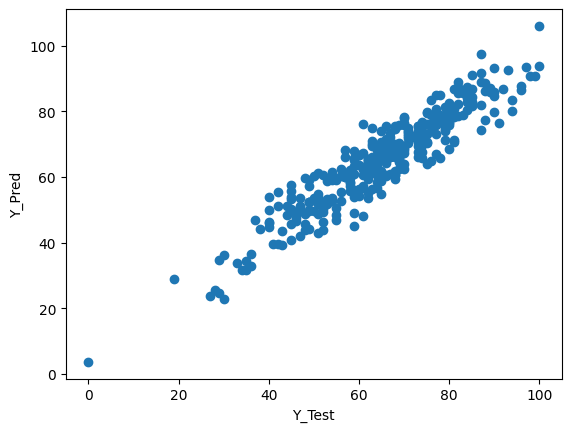

In [91]:
# Plot Y_pred against Y_test
plt.scatter(y_test,y_pred)
plt.xlabel("Y_Test")
plt.ylabel("Y_Pred")

<Axes: xlabel='math_score'>

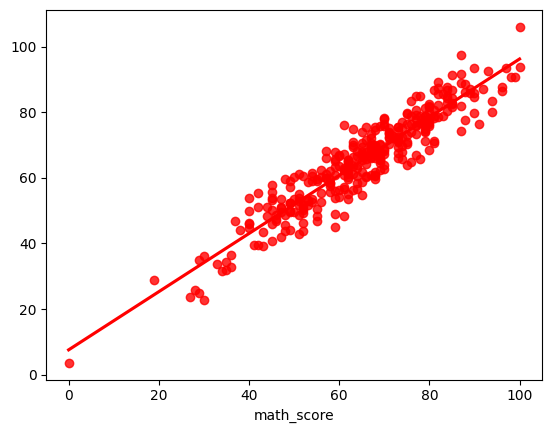

In [93]:
sns.regplot(x=y_test,y=y_pred,ci=None,color="red")


In [94]:
# Difference between Actual and Predicted Values
pred_df=pd.DataFrame({"Actual_Values":y_test,"Predicted_Values":y_pred,"Difference":y_test-y_pred})
pred_df

,Actual_Values,Predicted_Values,Difference
521,91,76.443742,14.556258
737,53,58.827765,-5.827765
740,80,76.885528,3.114472
660,74,76.890291,-2.890291
411,84,87.577625,-3.577625
...,...,...,...
506,68,74.555614,-6.555614
342,69,65.460049,3.539951
485,70,78.232278,-8.232278
711,80,79.987862,0.012138
